In [24]:
from pytweezer.servers.device_client import get_device
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.thorcam import ThorCam
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
rb_exp = get_device("Rb MotMaster")

In [16]:
thorcam: ThorCam = get_device("Rb ThorCam")

---

In [4]:
rb_exp.set_motmaster_experiment("RbTweezerBasic2026_2")
rb_exp.set_save_toggle(False)
rb_exp.set_run_until_stopped(False)

In [17]:
thorcam.set_trigger_source("bulb")
thorcam.set_roi(650, 600, 280, 600)

---

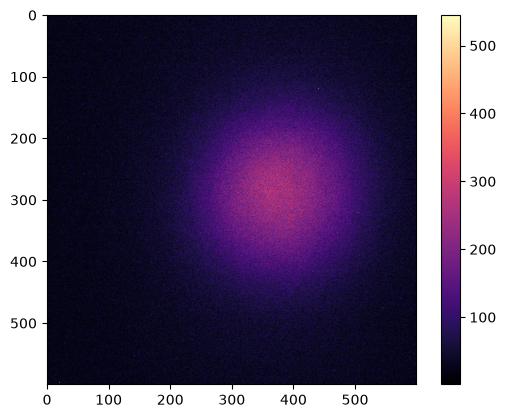

In [21]:
n_it = 10

rb_exp.set_iterations(n_it)
thorcam.setup_acquisition(n_it)
thorcam.start_acquisition()
rb_exp.start_motmaster_experiment({"tDelay1": 1000})
thorcam.stop_acquisition()
imgs = thorcam.acquire_n_frames(nframes=n_it, broadcast=True)

plt.imshow(imgs.mean(axis=0), cmap="magma")
plt.colorbar()

---

In [147]:
n_it = 10
rb_exp.set_iterations(n_it)

tau_list = np.arange(1, 1000, 50)

data = []
for it, tau in enumerate(tau_list):
    thorcam.setup_acquisition(n_it)
    thorcam.start_acquisition()
    rb_exp.start_motmaster_experiment({"tDelay1": int(tau)})
    thorcam.stop_acquisition()
    imgs = thorcam.acquire_n_frames(nframes=n_it, broadcast=True)
    data.append(imgs.mean(axis=0))
    print(f"It: {(it+1)}/{len(tau_list)}    |    Tau: {tau}")

It: 1/20    |    Tau: 1
It: 2/20    |    Tau: 51
It: 3/20    |    Tau: 101
It: 4/20    |    Tau: 151
It: 5/20    |    Tau: 201
It: 6/20    |    Tau: 251
It: 7/20    |    Tau: 301
It: 8/20    |    Tau: 351
It: 9/20    |    Tau: 401
It: 10/20    |    Tau: 451
It: 11/20    |    Tau: 501
It: 12/20    |    Tau: 551
It: 13/20    |    Tau: 601
It: 14/20    |    Tau: 651
It: 15/20    |    Tau: 701
It: 16/20    |    Tau: 751
It: 17/20    |    Tau: 801
It: 18/20    |    Tau: 851
It: 19/20    |    Tau: 901
It: 20/20    |    Tau: 951


In [148]:
# Import curve fitting libraries
from scipy.optimize import curve_fit

# Write a function for an elliptical gaussian
def elliptical_gaussian(x, y, A, x0, y0, sx, sy, theta, offset):
    """
    Returns the value of an elliptical Gaussian function at the given x and y coordinates.

    Parameters:
    - x: The x-coordinate(s) (can be a scalar or a numpy array).
    - y: The y-coordinate(s) (can be a scalar or a numpy array).
    - A: Amplitude of the Gaussian.
    - x0: x-coordinate of the center of the Gaussian.
    - y0: y-coordinate of the center of the Gaussian.
    - sx: Standard deviation in the x-direction.
    - sy: Standard deviation in the y-direction.
    - theta: Rotation angle in radians.
    - offset: Constant offset added to the Gaussian.

    Returns:
    - The value(s) of the elliptical Gaussian function at the specified coordinates.
    """
    # Rotate coordinates
    x_rot = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    y_rot = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)

    # Calculate the elliptical Gaussian
    return A * np.exp(-((x_rot**2 / (2 * sx**2)) + (y_rot**2 / (2 * sy**2)))) + offset

sx_list, sy_list, x0_list, y0_list = [], [], [], []
for img in data:
    # Fit the elliptical Gaussian to the image data
    x = np.arange(img.shape[1])
    y = np.arange(img.shape[0])
    x, y = np.meshgrid(x, y)
    p0 = (img.max(), img.shape[1]//2, img.shape[0]//2, 10, 10, 0, img.min())  # Initial guess for parameters
    popt, pcov = curve_fit(lambda xy, A, x0, y0, sx, sy, theta, offset: elliptical_gaussian(xy[0], xy[1], A, x0, y0, sx, sy, theta, offset).ravel(), (x.ravel(), y.ravel()), img.ravel(), p0=p0)

    # Return and save the sx and sy values
    A_fit, x0_fit, y0_fit, sx_fit, sy_fit, theta_fit, offset_fit = popt
    x0_list.append(x0_fit)
    y0_list.append(y0_fit)

    # Make all sx_fit and sy_fit values positive and sort them so that sx_fit is always the larger value
    sx_fit, sy_fit = sorted([abs(sx_fit), abs(sy_fit)], reverse=True)
    sx_list.append(sx_fit)
    sy_list.append(sy_fit)
    print(f"Fitted parameters: A={A_fit}, x0={x0_fit}, y0={y0_fit}, sx={sx_fit}, sy={sy_fit}, theta={theta_fit}, offset={offset_fit}")

Fitted parameters: A=1077.3404110472732, x0=270.2622160141844, y0=286.0118340868482, sx=30.82544856092462, sy=26.113269896105127, theta=9268324.137985932, offset=44.242236911213205
Fitted parameters: A=1087.086754030017, x0=270.724331749052, y0=286.15570948719846, sx=31.104404146187065, sy=26.320111453465053, theta=8392091.582928086, offset=44.05161608347961
Fitted parameters: A=1080.9905061457985, x0=271.8032594915571, y0=285.8110642546271, sx=31.990062471632246, sy=27.427511389208373, theta=9306470.99904172, offset=43.95416083336628
Fitted parameters: A=1061.5417114116965, x0=272.157409788502, y0=286.48599986042393, sx=33.30781320767856, sy=28.368132952106166, theta=8247061.584747805, offset=43.52839938256167
Fitted parameters: A=1026.6038859090688, x0=274.6455210444122, y0=286.2555408443048, sx=34.61877918820685, sy=30.187727450101878, theta=10339227.200785616, offset=43.374174291025845
Fitted parameters: A=947.891817527885, x0=277.964927278323, y0=284.9513509686898, sx=37.015531108

C:\Users\tweez\AppData\Local\Temp\ipykernel_48432\1479298510.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


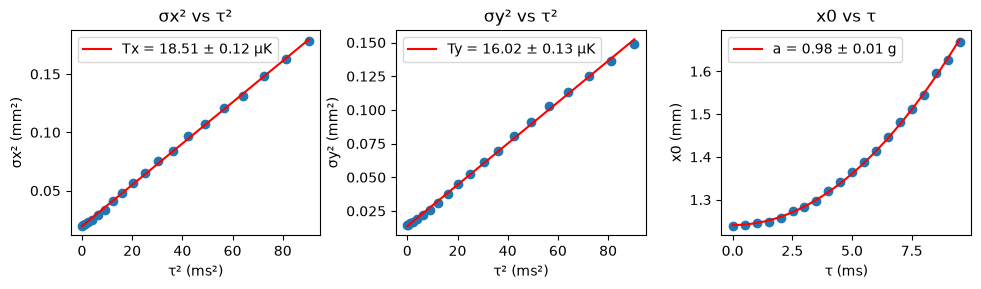

In [150]:
gamma = 1e3 / (194902.8581 * 1.12) # mm / px
MRb = 1.44316e-25  # kg
kB = 1.380649e-23  # J/K

tau_list = np.arange(1, 1000, 50)
tau_list_ms = tau_list * 1 / 100
tau_list_s = tau_list_ms * 1 / 1000

sx_array = np.array(sx_list) * gamma
sy_array = np.array(sy_list) * gamma
x0_array = np.array(x0_list) * gamma
y0_array = np.array(y0_list) * gamma

lin_fit = lambda x, m, c: m * x + c
px, pcovx = curve_fit(lin_fit, tau_list_ms**2, sx_array**2)
py, pcovy = curve_fit(lin_fit, tau_list_ms**2, sy_array**2)
t2_fit = np.linspace(0, tau_list_ms[-1]**2, 100)
sx2_fit = lin_fit(t2_fit, *px)
sy2_fit = lin_fit(t2_fit, *py)

mx = px[0]  # slope for sx^2 vs tau^2
my = py[0]  # slope for sy^2 vs tau^2

Tx = mx * MRb / kB * 1e6
Ty = my * MRb / kB * 1e6

mx_err = np.sqrt(np.diag(pcovx))[0]
my_err = np.sqrt(np.diag(pcovy))[0]

Tx_err = mx_err * MRb / kB * 1e6
Ty_err = my_err * MRb / kB * 1e6

# Plot sx_array, sy_array, x0_array all three side by side with respect to tau_list_ms
plt.figure(figsize=(10, 3), constrained_layout=True)
plt.subplot(1, 3, 1)
plt.scatter(tau_list_ms**2, sx_array**2)
plt.plot(t2_fit, sx2_fit, color='red', label=f"Tx = {Tx:.2f} ± {Tx_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σx² (mm²)')
plt.title('σx² vs τ²')

plt.subplot(1, 3, 2)
plt.scatter(tau_list_ms**2, sy_array**2)
plt.plot(t2_fit, sy2_fit, color='red', label=f"Ty = {Ty:.2f} ± {Ty_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σy² (mm²)')
plt.title('σy² vs τ²')

free_fall = lambda t, a, x0: 1/2 * a * t**2 + x0
param1, pcov1 = curve_fit(free_fall, tau_list_ms, x0_array)
t_fit = np.linspace(0, tau_list_ms[-1], 100)
x0_fit = free_fall(t_fit, *param1)

a = param1[0] # acceleration in pixels/ms²
a_err = np.sqrt(np.diag(pcov1))[0]

plt.subplot(1, 3, 3)
plt.scatter(tau_list_ms, x0_array)
plt.plot(t_fit, x0_fit, color='red', label=f"a = {a/(9.81/1000):.2f} ± {a_err/(9.81/1000):.2f} g")
plt.legend()
plt.xlabel('τ (ms)')
plt.ylabel('x0 (mm)')
plt.title('x0 vs τ')

plt.tight_layout()
plt.show()

In [22]:
n_it = 10
rb_exp.set_iterations(n_it)

tau_list = np.arange(1, 1000, 50)

data = []
for it, tau in enumerate(tau_list):
    thorcam.setup_acquisition(n_it)
    thorcam.start_acquisition()
    rb_exp.start_motmaster_experiment({"tDelay1": int(tau)})
    thorcam.stop_acquisition()
    imgs = thorcam.acquire_n_frames(nframes=n_it, broadcast=True)
    data.append(imgs.mean(axis=0))
    print(f"It: {(it+1)}/{len(tau_list)}    |    Tau: {tau}")

It: 1/20    |    Tau: 1
It: 2/20    |    Tau: 51
It: 3/20    |    Tau: 101
It: 4/20    |    Tau: 151
It: 5/20    |    Tau: 201
It: 6/20    |    Tau: 251
It: 7/20    |    Tau: 301
It: 8/20    |    Tau: 351
It: 9/20    |    Tau: 401
It: 10/20    |    Tau: 451
It: 11/20    |    Tau: 501
It: 12/20    |    Tau: 551
It: 13/20    |    Tau: 601
It: 14/20    |    Tau: 651
It: 15/20    |    Tau: 701
It: 16/20    |    Tau: 751
It: 17/20    |    Tau: 801
It: 18/20    |    Tau: 851
It: 19/20    |    Tau: 901
It: 20/20    |    Tau: 951


Fitted parameters: A=1084.1478979876092, x0=269.2799723343483, y0=287.19956328108987, sx=34.95693063073458, sy=30.52620908417103, theta=10892059.325879632, offset=44.977600093455656
Fitted parameters: A=1092.3442719145241, x0=270.1668997927742, y0=286.41448461154465, sx=35.21343363524826, sy=30.561588660252607, theta=9764373.652666183, offset=45.1367495868302
Fitted parameters: A=1095.2288791515261, x0=270.8423142511935, y0=287.8362385545922, sx=36.36602331913035, sy=31.698198967909587, theta=9774359.219768973, offset=45.78906291828673
Fitted parameters: A=1091.4270210963214, x0=272.8596653863851, y0=286.6928194932709, sx=37.77023868105736, sy=32.865109413489236, theta=9791562.657857386, offset=45.94969772907367
Fitted parameters: A=1079.1977199652217, x0=275.1928958200854, y0=286.71643784269656, sx=38.681516101912415, sy=34.06588298866742, theta=11939694.172869308, offset=45.652412811462966
Fitted parameters: A=1036.9050371578276, x0=278.1850223056791, y0=286.6883856702197, sx=40.4614

C:\Users\tweez\AppData\Local\Temp\ipykernel_18080\4192322130.py:112: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


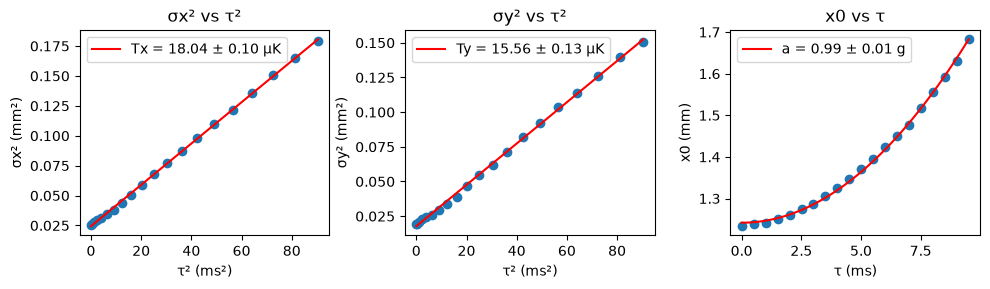

In [26]:
def elliptical_gaussian(x, y, A, x0, y0, sx, sy, theta, offset):
    """
    Returns the value of an elliptical Gaussian function at the given x and y coordinates.

    Parameters:
    - x: The x-coordinate(s) (can be a scalar or a numpy array).
    - y: The y-coordinate(s) (can be a scalar or a numpy array).
    - A: Amplitude of the Gaussian.
    - x0: x-coordinate of the center of the Gaussian.
    - y0: y-coordinate of the center of the Gaussian.
    - sx: Standard deviation in the x-direction.
    - sy: Standard deviation in the y-direction.
    - theta: Rotation angle in radians.
    - offset: Constant offset added to the Gaussian.

    Returns:
    - The value(s) of the elliptical Gaussian function at the specified coordinates.
    """
    # Rotate coordinates
    x_rot = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    y_rot = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)

    # Calculate the elliptical Gaussian
    return A * np.exp(-((x_rot**2 / (2 * sx**2)) + (y_rot**2 / (2 * sy**2)))) + offset

sx_list, sy_list, x0_list, y0_list = [], [], [], []
for img in data:
    # Fit the elliptical Gaussian to the image data
    x = np.arange(img.shape[1])
    y = np.arange(img.shape[0])
    x, y = np.meshgrid(x, y)
    p0 = (img.max(), img.shape[1]//2, img.shape[0]//2, 10, 10, 0, img.min())  # Initial guess for parameters
    popt, pcov = curve_fit(lambda xy, A, x0, y0, sx, sy, theta, offset: elliptical_gaussian(xy[0], xy[1], A, x0, y0, sx, sy, theta, offset).ravel(), (x.ravel(), y.ravel()), img.ravel(), p0=p0)

    # Return and save the sx and sy values
    A_fit, x0_fit, y0_fit, sx_fit, sy_fit, theta_fit, offset_fit = popt
    x0_list.append(x0_fit)
    y0_list.append(y0_fit)

    # Make all sx_fit and sy_fit values positive and sort them so that sx_fit is always the larger value
    sx_fit, sy_fit = sorted([abs(sx_fit), abs(sy_fit)], reverse=True)
    sx_list.append(sx_fit)
    sy_list.append(sy_fit)
    print(f"Fitted parameters: A={A_fit}, x0={x0_fit}, y0={y0_fit}, sx={sx_fit}, sy={sy_fit}, theta={theta_fit}, offset={offset_fit}")

gamma = 1e3 / (194902.8581 * 1.12) # mm / px
MRb = 1.44316e-25  # kg
kB = 1.380649e-23  # J/K

tau_list = np.arange(1, 1000, 50)
tau_list_ms = tau_list * 1 / 100
tau_list_s = tau_list_ms * 1 / 1000

sx_array = np.array(sx_list) * gamma
sy_array = np.array(sy_list) * gamma
x0_array = np.array(x0_list) * gamma
y0_array = np.array(y0_list) * gamma

lin_fit = lambda x, m, c: m * x + c
px, pcovx = curve_fit(lin_fit, tau_list_ms**2, sx_array**2)
py, pcovy = curve_fit(lin_fit, tau_list_ms**2, sy_array**2)
t2_fit = np.linspace(0, tau_list_ms[-1]**2, 100)
sx2_fit = lin_fit(t2_fit, *px)
sy2_fit = lin_fit(t2_fit, *py)

mx = px[0]  # slope for sx^2 vs tau^2
my = py[0]  # slope for sy^2 vs tau^2

Tx = mx * MRb / kB * 1e6
Ty = my * MRb / kB * 1e6

mx_err = np.sqrt(np.diag(pcovx))[0]
my_err = np.sqrt(np.diag(pcovy))[0]

Tx_err = mx_err * MRb / kB * 1e6
Ty_err = my_err * MRb / kB * 1e6

# Plot sx_array, sy_array, x0_array all three side by side with respect to tau_list_ms
plt.figure(figsize=(10, 3), constrained_layout=True)
plt.subplot(1, 3, 1)
plt.scatter(tau_list_ms**2, sx_array**2)
plt.plot(t2_fit, sx2_fit, color='red', label=f"Tx = {Tx:.2f} ± {Tx_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σx² (mm²)')
plt.title('σx² vs τ²')

plt.subplot(1, 3, 2)
plt.scatter(tau_list_ms**2, sy_array**2)
plt.plot(t2_fit, sy2_fit, color='red', label=f"Ty = {Ty:.2f} ± {Ty_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σy² (mm²)')
plt.title('σy² vs τ²')

free_fall = lambda t, a, x0: 1/2 * a * t**2 + x0
param1, pcov1 = curve_fit(free_fall, tau_list_ms, x0_array)
t_fit = np.linspace(0, tau_list_ms[-1], 100)
x0_fit = free_fall(t_fit, *param1)

a = param1[0] # acceleration in pixels/ms²
a_err = np.sqrt(np.diag(pcov1))[0]

plt.subplot(1, 3, 3)
plt.scatter(tau_list_ms, x0_array)
plt.plot(t_fit, x0_fit, color='red', label=f"a = {a/(9.81/1000):.2f} ± {a_err/(9.81/1000):.2f} g")
plt.legend()
plt.xlabel('τ (ms)')
plt.ylabel('x0 (mm)')
plt.title('x0 vs τ')

plt.tight_layout()
plt.show()

---

In [27]:
hamcam : ImagEMX2Camera = get_device("Rb HamCam")

In [29]:
hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 0, 0, 512, 512
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

Text(0.5, 1.0, 'Thor Camera')

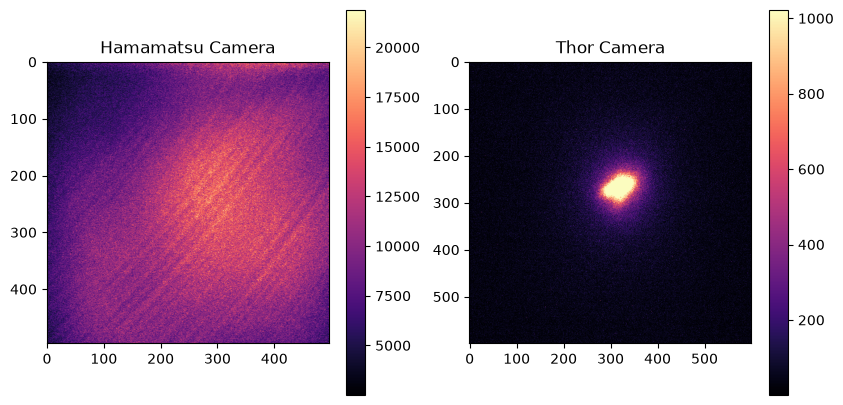

In [45]:
# Experiment and camera setup
n_iterations = 1

rb_exp.set_motmaster_experiment("RbTweezerBasic2026_2")
rb_exp.set_iterations(n_iterations)

hamcam.setup_acquisition("snap", n_iterations)
thorcam.setup_acquisition(n_iterations)
hamcam.start_acquisition()
thorcam.start_acquisition()

rb_exp.start_motmaster_experiment()

imgs_ham = hamcam.acquire_n_frames(n_iterations)
imgs_thor = thorcam.acquire_n_frames(nframes=n_iterations, broadcast=True)

imgs_ham_mean = imgs_ham.mean(axis=0)
imgs_thor_mean = imgs_thor.mean(axis=0)

# Plot imgs_ham_mean and imgs_thor_mean side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imgs_ham_mean, cmap="magma")
plt.colorbar()
plt.title("Hamamatsu Camera")
plt.subplot(1, 2, 2)
plt.imshow(imgs_thor_mean, cmap="magma")
plt.colorbar()
plt.title("Thor Camera")

---

In [2]:
from pytweezer.cpp import morph_tophat_cpp
from pytweezer.arduino import ArduinoPulser

In [3]:
arduino = ArduinoPulser("COM4", baudrate=9600, timeout=1)

In [4]:
startup_message = arduino.connect()

In [6]:
arduino.send_pulses(5)

'Firing exactly 5 pulses at 1 kHz...'